### Analisis de procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align=right width=150>
## TS4: Análisis de Fourier: Primeras nociones de estimación espectral
### Lanzavechia, Jerónimo

Aclaración: El formateo de los gráficos y las porciones del documento en Latex se hicieron con asistencia de Chat-GPT

## Introducción

En la teoría, las señales pueden representarse como funciones continuas e infinitamente densas, con un dominio continuo desde el $-\infty$ al $+\infty$. Analizar señales en la realidad implica que dichos fundamentos matemáticos no se cumplan, creando la necesidad de crear herramientas para estimar, por ejemplo, el valor de dicha señal a lo largo del tiempo, o para el caso de este trabajo semanal, su espectro.

La estimación espectral nace de que una señal no se puede analizar a infinito tiempo, y que las frecuencias no pueden analizarse de forma continua. El ventaneo y el muestreo de frecuencia darán lugar a cierta incertidumbre en el analisis de una señal en su dominio frecuencial.
Durante el proceso de estimación, podria ser de interés estimar con cierta selectividad el espectro, por ejemplo, tratando de aislar la señal de interés de cierto ruido, o querer poder distinguir de mejor forma las componentes del espectro. Para esto, se podría elegir alguna ventana particular. Esta selección en la ventana trae consigo dos cuestiones a considerar. Si la estimación esta muy alejada del "valor deseado" (aquel que se espera o se intuye/sabe que tiene el elemento a medir), se dice que hay cierto sesgo en la estimación. Si los valores de la medición varían mucho o poco de nuestro "valor deseado", se dice que hay mucha varianza en la estimación.

Para este trabajo semanal, se implementarán distintas ventanas con el objetivo de ver y comparar el sesgo y la varianza que presentan en la estimación espectral de señales de distintos SNR.

## Desarrollo
Se realizarán 200 realizaciones de señales de SNR = 3dB y SNR = 10dB a las cuales se les aplicará una ventana particular. Dicho ventaneo, y el número de realizaciones permitiran estimar el espectro de la señal, junto con un sesgo y una varianza correspondientes. Se buscará estimar la amplitud y la frecuencia de las señales. 

Las señales se presentan con la siguiente formula:

\begin{align}
    x(n)=a_0⋅sen(Ω_1⋅n)+n_a(n)
\end{align}

donde $Ω_1$ esta compuesto por:

\begin{align}
    Ω_1=Ω_0+f_r⋅2π/N
\end{align}

con $Ω_0 = π/2$ y con f_r dado por la siguiente distribución:

\begin{align}
    f_r∼\mathcal{U}(−2,2)
\end{align}

Será la variación de frecuencia.

Como la potencia será unitaria, $a_0=√2$

$n_a(n)$ estará dado por:
\begin{align}
    n_a(n)∼\mathcal{N}(0,\sigma²)
\end{align}

Será el ruido de la señal, $\sigma²$ es la varianza del mismo.

Tanto la variación de la frecuencia como el ruido serán generados con la función "mi_ruido" en mi_libreria.py.

In [28]:
#hecha para TS1
def mi_ruido(P,dist,dc,n,fs):
    """
    P = Potencia de la señal
    dc = componente de continua
    dist = distribucion (normal, uniform)
    n = numero de muestras
    """
    noise = []
    if dist == "normal":    
        for i in range(n):
            noise.append(np.random.normal(0,np.sqrt(P)) + dc)
    elif dist == "uniform":
        for i in range(n):
            A = np.sqrt(P*3)
            noise.append(np.random.uniform(-A,A) + dc)
            #La potencia media de una distribucion uniforme es (vmax - vmin)²/12
            #despejando, siendo que vmax = -vmin, queda que P = 4vmax²/12
            #simplificando, P = vmax²/3
            #la vmax me da una amplitud, siendo que la distribucion la centro en dc,
            #entonces vmax = A = sqrt(P*3)
    else:
        print("Distribucion no disponible")
        return noise
    
    tt =  np.arange(start = 0, stop = n/fs, step = 1/fs)
    return tt, noise

Para realizar las estimaciones de amplitud y frecuencia, se piden implementar los siguientes estimadores:

El de amplitud buscará en las 200 realizaciones los valores en $f = 250Hz$, por lo tanto, puede interpretarse como:
\begin{align}
   {\hat a}_0 =|X^i_w(Ω_0)|
\end{align}
A partir del cual se obtiene el sesgo de la siguiente forma, calculando su valor esperado(el promedio entre las amplitudes en $250Hz$):

\begin{align}
E\{ \hat{a_0}\} = \hat{\mu_a} = \frac{1}{R} \sum^{R-1}_{j=0} \hat{a_{j}}
\end{align}

\begin{align}
S_a = \mathop{E}\{ {\hat a}_0 \}  − a_0
\end{align}

Con varianza calculada desde np.var() usando esos valores, disponible en numpy

Y el de frecuencia buscará el argumento con mayor amplitud para las 200 realizaciones:

\begin{align}
\hat{Ω}^i_1 = \mathop{arg\ max}_f \{ \lvert X^i_w(Ω) \rvert \}
\end{align}

El sesgo y la varianza se calculan de la misma forma que para la amplitud.
Los valores medidos por el estimador de frecuencias se usarán para un histograma, y todos los sesgos y varianzas estarán en un tablas correspondientes a cada SNR.


Se utilizarán las siguientes librerías y constantes:

In [29]:
import numpy as np #importa numpy
import matplotlib.pyplot as plt #importa plot
import mi_libreria as lib #importa mi_libreria
import scipy.fft as scfft #mporta scipy para la fft
import scipy.signal.windows as window #importa scipy para ventanas

N = 1000 #número de muestras por realización
R = 200 #realizaciones
fs = 1000 #f de muestreo
A = np.sqrt(2) #amplitud del seno para 1W

### Generación de ondas

Para generar las 200 realizaciones a 1000 muestras cada una, se creó una matriz R x N producto de las realizaciones (cada una con una $f_r$ distinta) y la cantidad de muestras. Esta matriz luego se usó para la implementación de los 200 senos, a los cuales se les adicionó la matriz de R x N muestras de ruido ruidos, uno para cada realización. Se calculó la potencia requerida para el ruido a partir del SNR deseado, y se pasó a la función mi_ruido como parámetro.


In [30]:
#En la implementacion agregue para generar una uniforme, asi que la uso para eso

SNR = 3 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

####################para la frecuencia################
P = 2 #lo imagino como si tuviera una potencia de 2

tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_3dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_3dB_m

Para generar las señales ventaneadas, se multiplica el muestreo de los senos por las ventanas, siguiendo lo visto en el TS3:

\begin{align}
    x[n] = x[n]*[n] = X'[n]
\end{align}

Se usarán cuatro ventanas
- Rectangular (Ventana implicita)
- Flattop
- Blackmann - Harris (Resumida a Blackmann para el resto del trabajo)
- Coseno (Elegida para el trabajo)
Todas las ventanas se importaron de scipy.signal.windows

### Estimaciones

Con cada una de estas ventanas, se estudiará su sesgo y varianza al momento de estimar la amplitud y frecuencia de los senos generados. 
La estimación de frecuencia se verá en un histograma, y ambas estimaciones se compararán en una tabla. Cada estimación se realizará con las R (200) realizaciones y N (1000) muestras por realización. 

Los estimadores se implementaron de la siguiente forma:

- Estimador de amplitud:

    Se midió la amplitud de la señal en la frecuencia esperada (250Hz) y se seleccionaron las amplitudes de las realizaciones para promediarlas. Se asume que la distribución de amplitudes sigue una forma uniforme, con cada valor posible teniendo una misma probabilidad de ocurrir. Con ese promedio, se obtiene el valor esperado (visto en código).

- Estimador de frecuencia:
    Se buscó en cada realización la frecuencia con la amplitud mas alta para cada ventana. Se asume que la distribución de frecuencias sigue una forma uniforme, con cada valor posible teniendo una misma probabilidad de ocurrir. Con ese promedio, se obtiene el valor esperado (visto en código).

Con ambos estimadores y sus valores esperados, se calcula el sesgo. La varianza se calcula con la función np.var() de numpy. pasando como parametros las amplitudes o frecuencias medidas. 

El sesgo y varianza de amplitud se pueden ver en el cuadro o tabla comparativa seguidos de una "A".
El sesgo y varianza de frecuencia se pueden ver en el cuadro o tabla comparativa seguidos de una "F".

El estudio, cálculos y estimaciones se repritieron tanto para las señales con SNR a 3dB como a 10dB.

### Señal con SNR = 3dB | Espectro de densidad de potencia

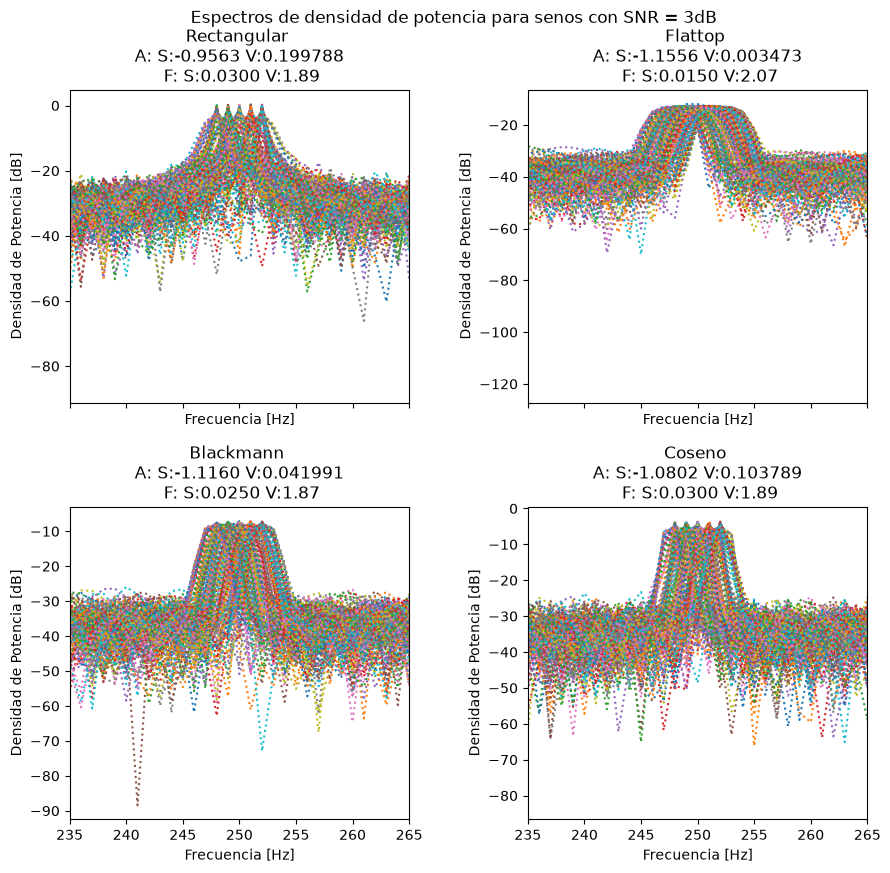

In [31]:
fig_3SNR, ((rectangular_3, flattop_3),( blackmann_3, coseno_3)) = plt.subplots(2,2, sharex=True)
fig_3SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 3dB")
fig_3SNR.tight_layout(h_pad = 3, w_pad = 3)
fig_3SNR.set_size_inches(9,9)

#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_3.set_title(f"Rectangular \n A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} \n F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_3.set_xlabel("Frecuencia [Hz]")
rectangular_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_3.plot(ww,modulo_db[i],':')
rectangular_3.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################

#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_3.set_title(f"Flattop \n A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} \n F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_3.set_xlabel("Frecuencia [Hz]")
flattop_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_3.plot(ww,modulo_db[i],':')

##############################################################################


#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_3.set_title(f"Blackmann \n A: S:{S_a_black:.4f} V:{V_a_black:.6f} \n F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_3.set_xlabel("Frecuencia [Hz]")
blackmann_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_3.plot(ww,modulo_db[i],':')

#############################################################################

#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_3.set_title(f"Coseno \n A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} \n F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_3.set_xlabel("Frecuencia [Hz]")
coseno_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_3.plot(ww,modulo_db[i],':')
#############################################################################

Las formas de onda obtenidas son distintas debido a que la forma de cada ventana es distinta. Se puede apreciar como cada realización contiene a la forma del espectro de densidad de potencia de la ventana. Los máximos se encuentran en los valores enteros de la frecuencia, a un máximo de 2fs/N de diferencia entre el centro (250Hz) y las frecuencias generadas por la variación dada por la distribución.
Cada de las transformadas de las ventanas va a tener un ancho de lobulo principal mas grande (Blackmann) o mas chico (rectangular) y al mismom tiempo mayor potencia de lobulos laterales (rectangular) o menor (Flattop). Estas diferencias llevan a distintos efectos en las estimaciones, todas teniendo el mismo número de muestras y ancho de ventana para todas. 

Para un SNR = 3dB

La Rectangular tiene su piso en aproximadamente 30dB, con picos de densidad de potencia distinguibles.
La Flattop tiene su piso en 40dB, con los picos practicamente planos e indistinguibles, que no alcanzan los 0dB.
La Blackmann tiene su piso cerca de los 40dB, con picos mas redondos que la rectangular, que no alcanzan los 0dB.
La Coseno tiene su piso cerca de 40dB, pero no tanto como la Blackmann, y picos con forma aproximada a la rectangular, que no alcanzan los 0dB,


### Histograma

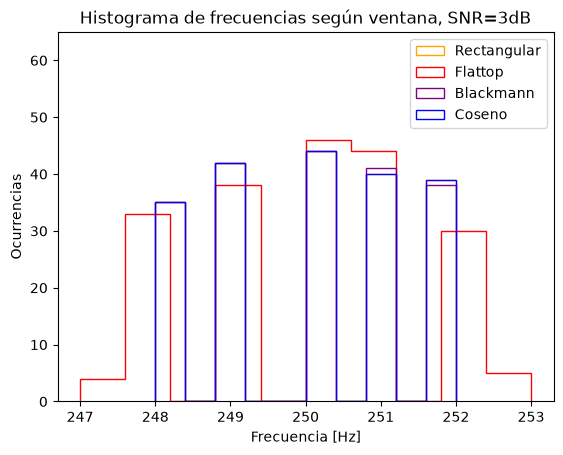

In [32]:
plt.figure(10)
plt.title("Histograma de frecuencias según ventana, SNR=3dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ocurrencias")
plt.hist(f_max_rec, color = 'orange', histtype='step', label="Rectangular")
plt.hist(f_max_flat, color = 'red', histtype='step', label = "Flattop")
plt.hist(f_max_black, color = 'purple', histtype='step', label = "Blackmann")
plt.hist(f_max_cos, color = 'blue', histtype='step',label = "Coseno")
plt.ylim(0,65)
plt.legend(loc = 'best')

Se puede ver como la ventana Blackmann y Coseno tuvieron las todas las ocurrencias mas centradas en los 250Hz, mientras que la Rectangular y la Flattop tuvieron ocurrencias incluso a 3fs/N alejadas de los 250Hz. Con la tabla de sesgo de varianza se termina de explicar esto.

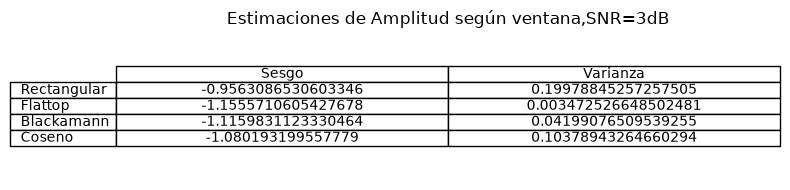

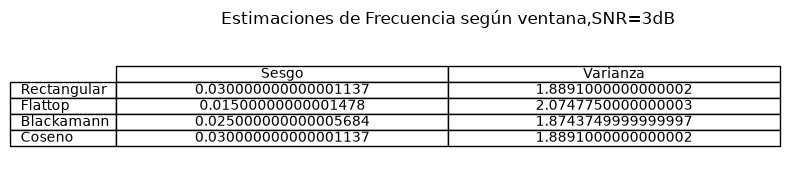

In [33]:
#Tablas de comparacion de amplitud/frecuencia y varianza

##arreglos de datos para tablas
datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(20,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(30,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()

Se observa como la forma de la ventana termina de influir en las estimaciones a través del sesgo y su varianza.
#### Amplitud
La ventana Rectangular presenta el menor sesgo para la amlplitud, pero con demasiada varianza en cuanto a su valor.
La ventana Flattop Tiene el mayor sesgo pero con la menor varianza.
La Blackmann termina teniendo un poco mas de sesgo que la Coseno, pero mucha menos varianza, casi la misma que la de la Flattop.

#### Frecuencia
La ventana Rectangular, Blackmann y Coseno presentan practicamente el mismo sesgo, con minimas variaciones en la varianza.
La ventana Flattop tiene el menor sesgo, pero con la mayor varianza.

El sesgo es algo corregible con ajuste de las herramientas de estimación, por medio de calibración alrededor del valor esperado. La varianza no se puede corregir y es propia del metodo de estimación. Por lo que se buscaría una ventana con la mejor relación sesgo/varianza para reducir la calibración y tener la menor varianza posible.

### Señal con SNR = 10dB | Espectro de densidad de potencia

Se repite la forma de generación y estimación de las amplitudes y frecuencias que el mostrado para 3dB. Se cambió el SNR a 10dB 

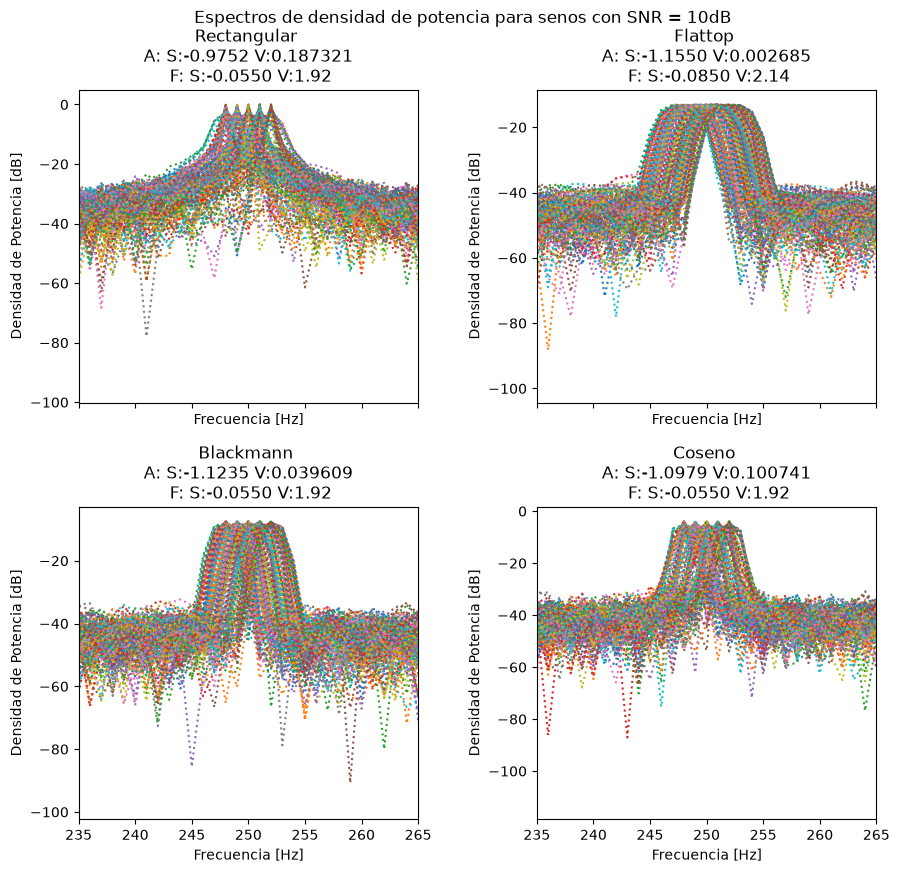

In [37]:
N = 1000
fs = 1000
A = np.sqrt(2)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
P = 2

SNR = 10 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
R = 200

####################para la frecuencia################
tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_10dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_10dB_m

#Ventanas SNR = 10dB

fig_10SNR, ((rectangular_10, flattop_10),( blackmann_10, coseno_10)) = plt.subplots(2,2, sharex=True)
fig_10SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 10dB")
fig_10SNR.tight_layout(h_pad = 3, w_pad = 3)
fig_10SNR.set_size_inches(9,9)

#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_10.set_title(f"Rectangular \n A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} \n F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_10.set_xlabel("Frecuencia [Hz]")
rectangular_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_10.plot(ww,modulo_db[i],':')
rectangular_10.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################

#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_10.set_title(f"Flattop \n A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} \n F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_10.set_xlabel("Frecuencia [Hz]")
flattop_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_10.plot(ww,modulo_db[i],':')

##############################################################################

#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_10.set_title(f"Blackmann \n A: S:{S_a_black:.4f} V:{V_a_black:.6f} \n F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_10.set_xlabel("Frecuencia [Hz]")
blackmann_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_10.plot(ww,modulo_db[i],':')

#############################################################################

#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_10.set_title(f"Coseno \n A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} \n F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_10.set_xlabel("Frecuencia [Hz]")
coseno_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_10.plot(ww,modulo_db[i],':')
#############################################################################

Para un SNR = 10dB

La Rectangular matiene su piso en aproximadamente 30dB, con picos de densidad de potencia distinguibles.
La Flattop tiene su piso en 40dB, con los picos practicamente planos e indistinguibles, que no alcanzan los 0dB.
La Blackmann tiene su piso cerca de los 40dB, con picos mas redondos que la rectangular, que no alcanzan los 0dB.
La Coseno tiene su piso cerca de 40dB, pero no tanto como la Blackmann, y picos con forma aproximada a la rectangular, que no alcanzan los 0dB.


### Histograma

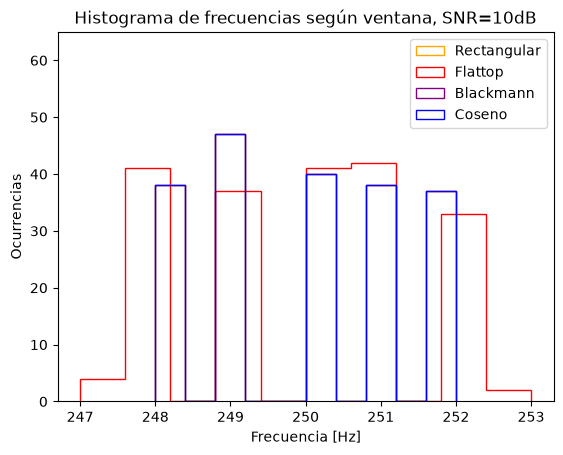

In [38]:
plt.figure(40)
plt.title("Histograma de frecuencias según ventana, SNR=10dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ocurrencias")
plt.hist(f_max_rec, color = 'orange', histtype='step', label="Rectangular")
plt.hist(f_max_flat, color = 'red', histtype='step', label = "Flattop")
plt.hist(f_max_black, color = 'purple', histtype='step', label = "Blackmann")
plt.hist(f_max_cos, color = 'blue', histtype='step',label = "Coseno")
plt.ylim(0,65)
plt.legend(loc = 'best')

Se puede ver como la ventana Blackmann y Coseno tuvieron las todas las ocurrencias mas centradas en los 250Hz, mientras que la Rectangular y la Flattop tuvieron ocurrencias incluso a 3fs/N alejadas de los 250Hz. Con la tabla de sesgo de varianza se termina de explicar esto.

## Estimaciones

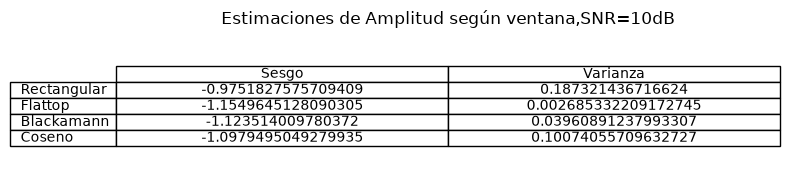

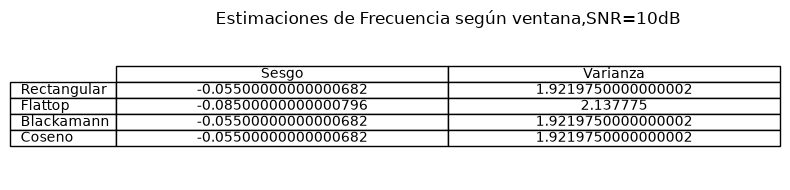

In [39]:

##arreglos de datos para tablas

datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(50,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=10dB")
tabla_a_10dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(60,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=10dB")
tabla_f_10dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()

Se observa como la forma de la ventana termina de influir en las estimaciones a través del sesgo y su varianza.
#### Amplitud
La ventana Rectangular presenta el menor sesgo para la amlplitud, pero con demasiada varianza en cuanto a su valor.
La ventana Flattop Tiene el mayor sesgo pero con la menor varianza.
La Blackmann termina teniendo un poco mas de sesgo que la Coseno, pero mucha menos varianza, en este caso algo mas que con los 3dB de SNR.

#### Frecuencia
La ventana Rectangular, Blackmann y Coseno presentan practicamente el mismo sesgo, con minimas variaciones en la varianza.
La ventana Flattop tiene el menor sesgo, pero con la mayor varianza.

Se puede apreciar como variaron los sesgos y varianzas con respecto al cambio del SNR

## Conclusiones

A través de las estimaciones, se pudo probar el efecto que tiene analizar diferentes señales a una determinada cantidad de realizaciones junto a la selección de alguna ventana.
El efecto que tendra una ventana al estimar los valores como la amplitud y la frecuencia de un tono dependeran de la forma de la ventana. Algunas son mas selectivas pero con un piso de potencia mucho mas alto, mientras que otras tienen menos selectividad pero un piso de potencia mucho mas bajo. Estos pisos se deben al desparramo espectral producto de la convolución por señales de frecuencia multiplo no entero de 2π.
Esto puede producir que ciertas componentes de interes queden tapadas por el piso de densidad de potencia, sumado al ruido insertado, haciendo de suma importancia la elección de una ventana apropiada.

Las estimaciones presentan un sesgo y una varianza; que tan lejos estan del valor deseado y que tanto varían de ese valor.
El sesgo es algo corregible con ajuste de las herramientas de estimación, por medio de calibración alrededor del valor esperado. La varianza no se puede corregir y es propia del metodo de estimación. Por lo que se buscaría una ventana con la mejor relación sesgo/varianza para reducir la calibración y tener la menor varianza posible.

## Referencias
* Holton, Thomas (2021). Digital Signal Processing - Principles and Applications. Cambridge University Press